# Stitched waterfall: the 29_n15 `Optimal` two-segment scan

This notebook is the [`waterfall_plot.ipynb`](waterfall_plot.ipynb) machinery applied to a
single dataset that was captured in **two overlapping segments** and must be **stitched into
one continuous scan** before the usual waterfall is meaningful.

The dataset lives at
`data/focusing_images/29_n15_Full/29_n15_Full/Optimal/`, with two subfolders:

* `0mm-25mm/l=<n>/`  — 51 frames, `positions.csv` running 0.0 → 25.0 mm,
* `20mm-45mm/l=<n>/` — 51 frames, `positions.csv` **also** running 0.0 → 25.0 mm.

The second segment's `positions.csv` is **local to that segment** (it starts back at 0), so
its true global $z$ is `local_z + offset`. The folder name suggests `offset ≈ 20 mm`, but the
label is only approximate.

**The overlap is short.** In the shared band the beam is converging fast: segment 1's last
frame ($z=25$ mm) already shows a *narrower* donut than segment 2's *first* frame. The two
width-vs-$z$ curves only share a band a couple of mm wide, so the segments image only ~2 mm of
**common physical planes** — you cannot make them overlap over a long span, there simply is no
long shared region. What you *can* do is slide segment 2 so its width curve sits on top of
segment 1's over that shared band; there the two lie on each other to well under a pixel.

**We set the offset by hand, per $\ell$.** Rather than auto-search (which, on monotonic width
curves with a short overlap, is easily fooled into shrinking the comparison window), the
offset for each charge is a single number you type in `OFFSETS_MM` below. A diagnostic plots
your chosen offset against the width curves so you can nudge each value until the two lie on
top of each other. Good starting values (~22–23 mm) are filled in.

**What this notebook does, per topological charge $\ell$:**

1. Process each segment independently with the base pipeline (centroid tracking → transverse
   slice → per-segment waterfall), keeping each segment's *local* $z$, plus a per-frame
   **beam-width** trace (transverse RMS radius of the slice).
2. Place segment 2 at `local_z + OFFSETS_MM[ell]` — the hand-set offset for that charge.
3. **Stitch** by resampling each segment's waterfall onto one common global-$z$ grid (linear
   interpolation in $z$, so a sub-frame offset is honoured), then build the overlap **three
   ways** side by side — *linear cross-fade*, *average*, and *hard cut at the overlap
   midpoint*.
4. Draw the stitched waterfalls (one per $\ell$) and a per-run centroid diagnostic, exactly as
   the base notebook does, and print a summary table.

Outputs go under `outputs/waterfalls_stitched/`.


In [37]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    """Walk up to the directory holding pyproject.toml (see the base notebook)."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
OPTIMAL_ROOT = DATA_ROOT / "29_n15_Full" / "29_n15_Full" / "Optimal"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfalls_stitched"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"repo root    : {REPO_ROOT}")
print(f"Optimal root : {OPTIMAL_ROOT}")
print(f"figures      : {OUT_ROOT}")
assert OPTIMAL_ROOT.is_dir(), f"missing {OPTIMAL_ROOT}"

repo root    : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
Optimal root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/data/focusing_images/29_n15_Full/29_n15_Full/Optimal
figures      : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/outputs/waterfalls_stitched


## Tunables

The two segment folders and their **nominal** starting global $z$ are declared here. Only
`SEG2_NOMINAL_START_MM` is a guess (from the folder name); the real value is measured in the
alignment step and reported — this number just seeds the search window and the diagnostic.

The slicing / centroid knobs are copied verbatim from the base notebook so the two analyses
are directly comparable.

In [38]:
RUN_LABEL = "29_n15_Optimal"

SEGMENTS = {                       # segment label -> folder, nominal global start (mm)
    "0-25":  {"dir": OPTIMAL_ROOT / "0mm-25mm",  "nominal_start_mm": 0.0},
    "20-45": {"dir": OPTIMAL_ROOT / "20mm-45mm", "nominal_start_mm": 20.0},
}
SEG1, SEG2 = "0-25", "20-45"       # first (reference) and second (shifted) segment

ELLS = [0, 1, 2, 3, 4, 5]          # charges present in both segments

STEP_MM = 0.5                      # stage step; also the fallback if a positions.csv is odd

# --- slicing (verbatim from waterfall_plot.ipynb) -------------------------
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200

# --- centroid finding (verbatim) ------------------------------------------
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200
# --------------------------------------------------------------------------

if SLICE_AXIS not in ("x", "y"):
    raise ValueError(f"SLICE_AXIS must be 'x' or 'y', got {SLICE_AXIS!r}")
print(f"slicing along {SLICE_AXIS}")


slicing along x


## Frame loading, background, centroid — unchanged from the base notebook

Identical helpers to `waterfall_plot.ipynb`: frames ordered by the trailing `_NNNN` index,
loaded as `float32`; background = median of a border strip; centroid = background-subtracted,
thresholded intensity centroid refined within a window. A `Segment` here is just one
`l=<n>` folder of one of the two halves.

In [39]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


@dataclass(frozen=True)
class Segment:
    """One `l=<n>` folder within one of the two halves of the scan."""

    seg: str          # "0-25" or "20-45"
    ell: int
    directory: Path
    nominal_start_mm: float


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    """Local z (mm) from positions.csv, falling back to index*STEP_MM if it is unusable."""
    csv = directory / "positions.csv"
    if csv.is_file():
        table = pd.read_csv(csv)
        by_name = dict(zip(table["image"], table["position_mm"]))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
        print(f"  ! {directory.name}: positions.csv does not name every frame — "
              f"inferring local z = index * {STEP_MM} mm")
    else:
        print(f"  ! {directory.name}: no positions.csv — inferring local z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())

## Process one segment into a waterfall + a registration feature

`process_segment` is the base notebook's `process_dataset`, trimmed to this dataset (every
folder here has a clean `positions.csv`) and extended to also return a per-frame **beam-width**
trace used for alignment.

For each already-centred, background-subtracted slice, the width is the intensity-weighted
transverse **RMS radius** about the centre. On-axis intensity is the central column of the
(centred) slice. Both are returned; `ALIGN_FEATURE` picks which one drives the registration.

In [40]:
@dataclass
class SegWaterfall:
    """One segment of one ell: its waterfall on *local* z, plus registration features."""

    seg: str
    ell: int
    nominal_start_mm: float
    waterfall: np.ndarray     # (n_z, n_s), NOT yet peak-normalised (raw, bg-subtracted)
    s_px: np.ndarray          # (n_s,) transverse coord about the centre
    z_local: np.ndarray       # (n_z,) local z (mm)
    centroid_y: np.ndarray          # FITTED straight-line centroid actually used
    centroid_x: np.ndarray
    centroid_y_raw: np.ndarray      # raw per-frame centroid, kept for diagnostics
    centroid_x_raw: np.ndarray
    centroid_w: np.ndarray          # per-frame brightness weight used in the fit
    width_px: np.ndarray      # (n_z,) transverse RMS radius per frame
    onaxis: np.ndarray        # (n_z,) central-column intensity per frame


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def segment_raw_centroids(segment: Segment):
    """Pass 1: load a segment's frames and return (z_local, centroid_y,
    centroid_x, weight) -- the RAW per-frame centroid and brightness, before the
    shared straight-line fit."""
    paths = frame_paths(segment.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {segment.directory}")
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3): row, col, brightness
    return z_local, cen[:, 0], cen[:, 1], cen[:, 2]


def process_segment(segment: Segment, centroid_y: np.ndarray, centroid_x: np.ndarray,
                    centroid_y_raw: np.ndarray, centroid_x_raw: np.ndarray,
                    centroid_w: np.ndarray) -> SegWaterfall:
    """Pass 2: build one segment's waterfall on the supplied FITTED straight-line
    centroid (no per-frame wobble).  Frames are reloaded here (released after the
    raw-centroid pass) so peak memory stays at a single segment."""
    paths = frame_paths(segment.directory)
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)  # raw, not peak-normalised
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return SegWaterfall(
        seg=segment.seg, ell=segment.ell, nominal_start_mm=segment.nominal_start_mm,
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x,
        centroid_y_raw=centroid_y_raw, centroid_x_raw=centroid_x_raw, centroid_w=centroid_w,
        width_px=width_px, onaxis=onaxis,
    )

## Process both segments, for every $\ell$

In [41]:
# Straight-line centroid: ONE shared slope for the whole run (every ell and
# segment), each segment keeps its own offset; then build every segment on its
# fitted line instead of the wobbling per-frame centroid.
#   pass 1: raw per-frame centroid + brightness for every (ell, segment)
#   fit:    one shared-slope line for both centroid axes
#   pass 2: rebuild each segment on its fitted centroid line (frames reloaded,
#           so peak memory stays at a single segment).
from centroid_lines import fit_centroid_lines

raw_sections: dict[tuple[int, str], dict] = {}
segment_objs: dict[tuple[int, str], Segment] = {}
for ell in ELLS:
    for seg_label, info in SEGMENTS.items():
        directory = info["dir"] / f"l={ell}"
        segment = Segment(seg_label, ell, directory, info["nominal_start_mm"])
        z_local, cy, cx, w = segment_raw_centroids(segment)
        raw_sections[(ell, seg_label)] = dict(z=z_local, cy=cy, cx=cx, w=w)
        segment_objs[(ell, seg_label)] = segment

lines, (slope_y, slope_x) = fit_centroid_lines(raw_sections)
print(f"shared centroid slope (y, x) = ({slope_y:+.3f}, {slope_x:+.3f}) px/mm\n")

segments: dict[int, dict[str, SegWaterfall]] = {ell: {} for ell in ELLS}
for (ell, seg_label), segment in segment_objs.items():
    r = raw_sections[(ell, seg_label)]
    cy_fit, cx_fit = lines[(ell, seg_label)]
    sw = process_segment(segment, cy_fit, cx_fit, r["cy"], r["cx"], r["w"])
    segments[ell][seg_label] = sw
    print(f"{seg_label:>6}  l={ell}  {str(sw.waterfall.shape):>12}  "
          f"local z {sw.z_local.min():.1f}..{sw.z_local.max():.1f} mm")
print("\nboth segments processed for every ell")


  0-25  l=0     (51, 401)  local z 0.0..25.0 mm
 20-45  l=0     (51, 401)  local z 0.0..25.0 mm
  0-25  l=1     (51, 401)  local z 0.0..25.0 mm
 20-45  l=1     (51, 401)  local z 0.0..25.0 mm
  0-25  l=2     (51, 401)  local z 0.0..25.0 mm
 20-45  l=2     (51, 401)  local z 0.0..25.0 mm
  0-25  l=3     (51, 401)  local z 0.0..25.0 mm
 20-45  l=3     (51, 401)  local z 0.0..25.0 mm
  0-25  l=4     (51, 401)  local z 0.0..25.0 mm
 20-45  l=4     (51, 401)  local z 0.0..25.0 mm
  0-25  l=5     (51, 401)  local z 0.0..25.0 mm
 20-45  l=5     (51, 401)  local z 0.0..25.0 mm

both segments processed for every ell


## Set the segment-2 offset, per $\ell$ (edit `OFFSETS_MM` by hand)

Segment 2's global $z$ is `local_z + offset`. Pick each charge's `offset` so its width curve
lands on segment 1's over the shared band — the next cell plots exactly that, so this is a
look-and-nudge loop:

* too **small** → segment 2 sits to the left, its curve rides **above** segment 1's;
* too **large** → segment 2 sits to the right, its curve drops **below** segment 1's;
* just right → the orange curve lies on the blue one across the overlap.

The values below (~22–23 mm) already give a sub-pixel match for the donuts; change any number
and re-run from here. $\ell=0$ is a Gaussian (its width behaves differently), so it has no
sharp match — its default just follows the donut consensus.


In [42]:
# Global start of segment 2 (mm), one value per l. EDIT THESE BY HAND.
# The next cell overlays each choice on the width curves so you can tune them.
OFFSETS_MM = {
    0: 23.0,   # Gaussian: no sharp match, follows the donut consensus
    1: 23.0,
    2: 23.0,
    3: 23.0,
    4: 23.0,
    5: 23.0,
}

assert set(OFFSETS_MM) == set(ELLS), "OFFSETS_MM must have exactly one entry per ell in ELLS"

nominal_off = SEGMENTS[SEG2]["nominal_start_mm"] - SEGMENTS[SEG1]["nominal_start_mm"]
for ell in ELLS:
    print(f"  l={ell}: segment 2 starts at global z = {OFFSETS_MM[ell]:.2f} mm "
          f"(nominal {nominal_off:.1f})")


  l=0: segment 2 starts at global z = 23.00 mm (nominal 20.0)
  l=1: segment 2 starts at global z = 23.00 mm (nominal 20.0)
  l=2: segment 2 starts at global z = 23.00 mm (nominal 20.0)
  l=3: segment 2 starts at global z = 23.00 mm (nominal 20.0)
  l=4: segment 2 starts at global z = 23.00 mm (nominal 20.0)
  l=5: segment 2 starts at global z = 23.00 mm (nominal 20.0)


### Check the offsets: do the width curves line up?

For each $\ell$, the two beam-width traces on global $z$: segment 1 (blue), segment 2 at your
hand-set `OFFSETS_MM[ell]` (orange), and — faint, for reference — segment 2 at the nominal
offset (grey). A good offset has the orange curve lying on the blue one through the shared
band. If it rides above or below, nudge that charge's number in the cell above and re-run.

No searching happens here — this only *shows* the offsets you set, so what you see is exactly
what gets stitched.


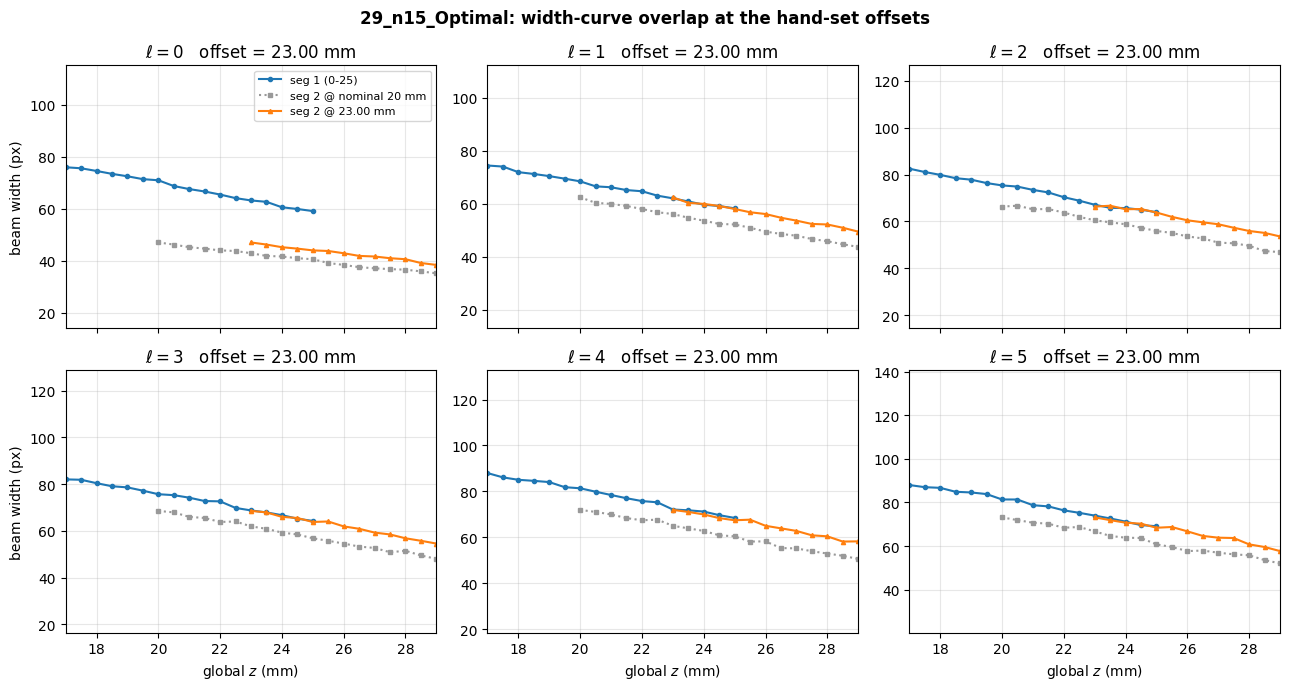

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)

for ell, ax in zip(ELLS, axes.ravel()):
    s1, s2 = segments[ell][SEG1], segments[ell][SEG2]
    ax.plot(s1.z_local, s1.width_px, "o-", ms=3, color="C0",
            label=f"seg 1 ({SEG1})")
    ax.plot(s2.z_local + nominal_off, s2.width_px, "s:", ms=2.5, color="0.6",
            label=f"seg 2 @ nominal {nominal_off:.0f} mm")
    ax.plot(s2.z_local + OFFSETS_MM[ell], s2.width_px, "^-", ms=3, color="C1",
            label=f"seg 2 @ {OFFSETS_MM[ell]:.2f} mm")

    # zoom to the shared band so the match (or mismatch) is easy to judge
    ov_lo = max(s1.z_local[0], s2.z_local[0] + OFFSETS_MM[ell])
    ov_hi = min(s1.z_local[-1], s2.z_local[-1] + OFFSETS_MM[ell])
    ax.set_xlim(ov_lo - 6, ov_hi + 4)
    ax.set_title(f"$\\ell={ell}$   offset = {OFFSETS_MM[ell]:.2f} mm")
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes[:, 0]:
    ax.set_ylabel("beam width (px)")
for ax in axes[-1, :]:
    ax.set_xlabel("global $z$ (mm)")
fig.suptitle(f"{RUN_LABEL}: width-curve overlap at the hand-set offsets", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "alignment_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## Stitch the two waterfalls onto one global-$z$ grid

The recovered offset is a **sub-frame** value (e.g. 22.45 mm, not a whole number of 0.5 mm
steps), so segment 2's frames do **not** land on segment 1's grid. Rather than round it away
— which would reintroduce up to a quarter-step seam — we build one uniform global grid at
`STEP_MM` spanning $0 \to$ (seg-2 end) and **resample each segment's waterfall onto it by
linear interpolation in $z$**, column by column (each transverse pixel independently). This
places segment 2 at its true global $z = z_\text{local} + $ `SEG2_START_MM` to sub-frame
precision, so the widths — and hence the caustic — line up across the seam.

On the common grid, rows are then classified as seg-1-only, seg-2-only, or overlap, and the
overlap is blended three ways:

* **crossfade** — a linear ramp from segment 1 to segment 2 across the overlap (smooth seam),
* **average**  — the mean of the two,
* **hardcut**  — segment 1 up to the overlap midpoint, segment 2 after.

Because the segments are now correctly co-registered in $z$, hardcut should be seamless too:
the two maps agree at the cut. Each blended map is peak-normalised **after** stitching so
colours are comparable across the whole $0 \to \sim45$ mm scan.

In [44]:
BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    ell: int
    mode: str
    waterfall: np.ndarray   # (n_z, n_s) peak-normalised, on the common global grid
    s_px: np.ndarray
    z_mm: np.ndarray        # (n_z,) uniform global z
    centroid_y: np.ndarray  # on the common grid (for diagnostics)
    centroid_x: np.ndarray

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src: np.ndarray, water_src: np.ndarray, z_grid: np.ndarray):
    """Linear-interpolate a (n_z, n_s) map from z_src onto z_grid, per transverse column.

    Returns (resampled_map, covered_mask): rows of z_grid outside z_src are 0 and masked out.
    """
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        # np.interp per column; vectorise over columns via list-comp (n_s ~ 401, cheap)
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1
        )
    return out, covered


def stitch(ell: int, seg2_start_mm: float, mode: str, z_grid: np.ndarray) -> Stitched:
    s1, s2 = segments[ell][SEG1], segments[ell][SEG2]
    assert np.array_equal(s1.s_px, s2.s_px), "segments cropped to different transverse extents"
    s_px = s1.s_px

    z1 = s1.z_local                       # seg 1 local z is already global (starts at 0)
    z2 = s2.z_local + seg2_start_mm       # seg 2 shifted to global z

    m1, cov1 = _resample_map(z1, s1.waterfall, z_grid)
    m2, cov2 = _resample_map(z2, s2.waterfall, z_grid)
    overlap = cov1 & cov2

    # per-row weight given to seg 1 (seg 2 gets 1 - w1); only matters inside the overlap
    w1 = np.where(cov1 & ~cov2, 1.0, np.where(cov2 & ~cov1, 0.0, 0.5))
    if overlap.any():
        z_ov = z_grid[overlap]
        lo, hi = z_ov.min(), z_ov.max()
        if mode == "average":
            w1[overlap] = 0.5
        elif mode == "hardcut":
            w1[overlap] = np.where(z_ov <= 0.5 * (lo + hi), 1.0, 0.0)
        else:  # crossfade: 1 at overlap start -> 0 at overlap end
            w1[overlap] = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo else 0.5

    w1 = w1[:, None]
    water = w1 * m1 + (1.0 - w1) * m2
    covered_any = cov1 | cov2
    water[~covered_any] = 0.0

    peak = float(water.max())
    if peak > 0:
        water /= peak

    # centroids on the common grid: seg 1 where it exists, else seg 2 (interpolated in z)
    cy = np.where(cov1, np.interp(z_grid, z1, s1.centroid_y, left=np.nan, right=np.nan), np.nan)
    cx = np.where(cov1, np.interp(z_grid, z1, s1.centroid_x, left=np.nan, right=np.nan), np.nan)
    fill = ~cov1 & cov2
    cy[fill] = np.interp(z_grid[fill], z2, s2.centroid_y)
    cx[fill] = np.interp(z_grid[fill], z2, s2.centroid_x)

    return Stitched(ell, mode, water, s_px, z_grid, cy, cx)


# one common global grid for every ell: 0 .. furthest seg-2 end, at STEP_MM
_z2_end = segments[ELLS[0]][SEG2].z_local[-1] + max(OFFSETS_MM.values())
Z_GRID = np.arange(0.0, _z2_end + 0.5 * STEP_MM, STEP_MM)

# overlap band (for the centroid seam marker), using a typical offset
_typical_off = float(np.median(list(OFFSETS_MM.values())))
OV_LO_MM = segments[ELLS[0]][SEG2].z_local[0] + _typical_off
OV_HI_MM = segments[ELLS[0]][SEG1].z_local[-1]

stitched: dict[int, dict[str, Stitched]] = {ell: {} for ell in ELLS}
for ell in ELLS:
    for mode in BLEND_MODES:
        stitched[ell][mode] = stitch(ell, OFFSETS_MM[ell], mode, Z_GRID)
    st = stitched[ell]["crossfade"]
    print(f"l={ell}: stitched -> {st.waterfall.shape}  z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm  "
          f"brightest at {st.brightest_z:.1f} mm")

l=0: stitched -> (97, 401)  z 0.0..48.0 mm  brightest at 43.5 mm
l=1: stitched -> (97, 401)  z 0.0..48.0 mm  brightest at 46.5 mm
l=2: stitched -> (97, 401)  z 0.0..48.0 mm  brightest at 48.0 mm
l=3: stitched -> (97, 401)  z 0.0..48.0 mm  brightest at 48.0 mm
l=4: stitched -> (97, 401)  z 0.0..48.0 mm  brightest at 48.0 mm
l=5: stitched -> (97, 401)  z 0.0..48.0 mm  brightest at 48.0 mm


## Compare the three overlap blends

One row per $\ell$, one column per blend mode, sharing the $z$ axis and a single 0–1
colourbar. The dashed lines mark the overlap region — this is where the three modes differ.
Now that the segments are co-registered in $z$ (widths matched), the caustic arms should run
**straight through the overlap with no kink**, and even `hardcut` should be seamless — any
residual ledge would signal a leftover $z$ or intensity mismatch. `crossfade` still gives the
smoothest seam and `average` sits between. Pick the mode that reads cleanest and set it as
`CHOSEN_BLEND` in the next cell.

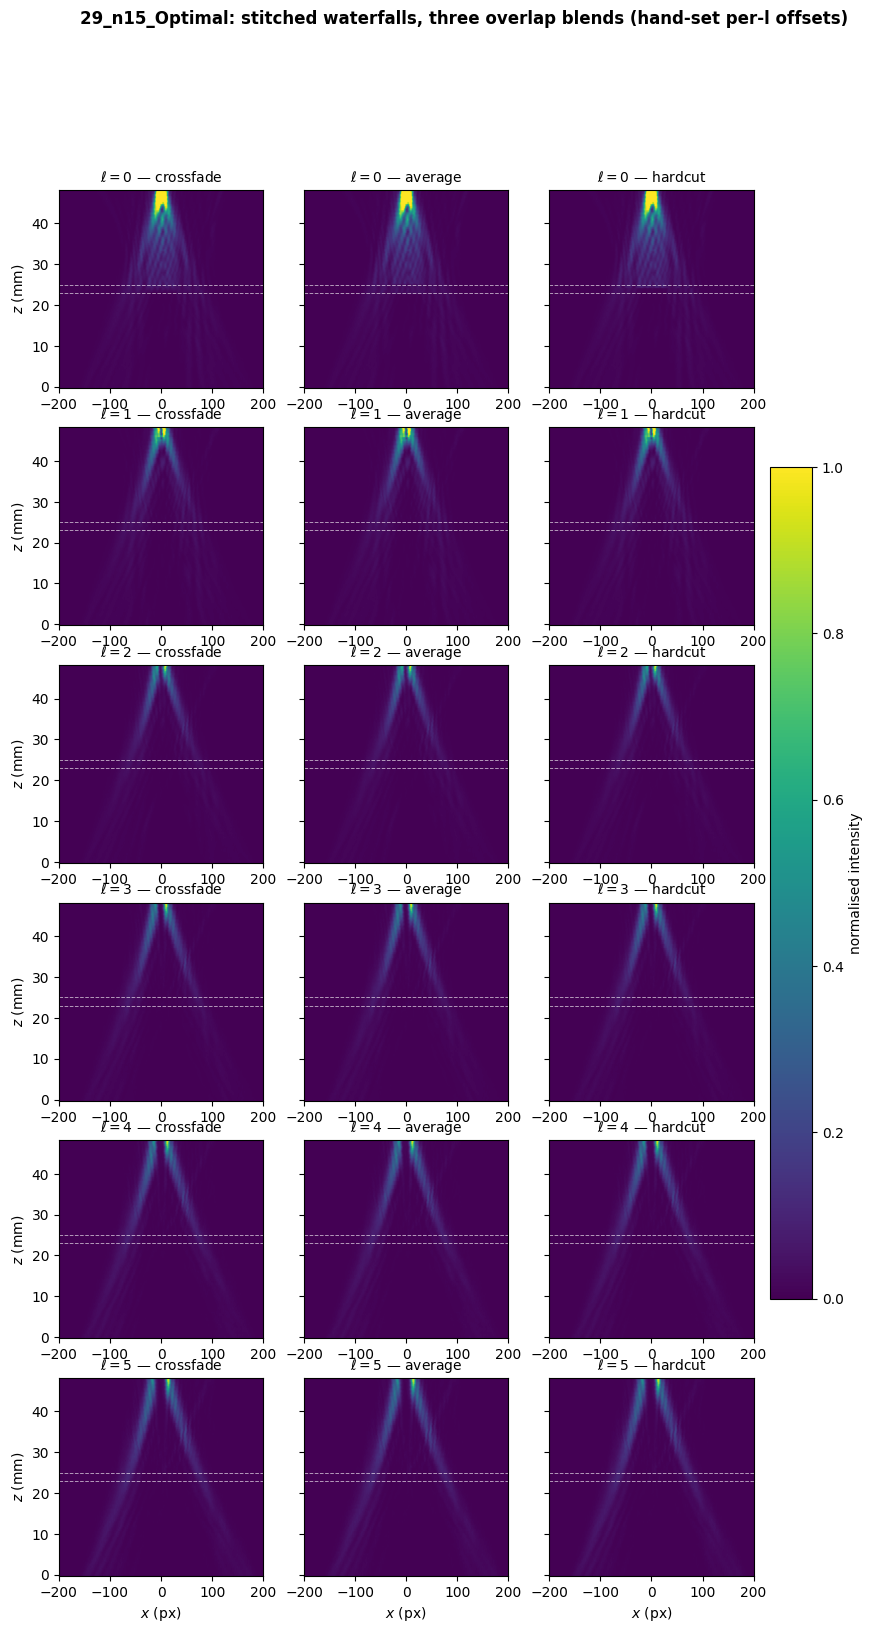

In [45]:
def draw_waterfall(ax, water, s_px, z_mm, title):
    dz = float(np.median(np.diff(z_mm))) if z_mm.size > 1 else STEP_MM
    im = ax.imshow(water, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                   extent=[s_px[0], s_px[-1], z_mm[0] - dz / 2, z_mm[-1] + dz / 2])
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
    ax.set_ylabel("$z$ (mm)")
    ax.set_title(title, fontsize=10)
    return im


# overlap band for reference lines (OV_LO_MM / OV_HI_MM come from the stitch cell)
fig, axes = plt.subplots(len(ELLS), len(BLEND_MODES),
                         figsize=(3.2 * len(BLEND_MODES) + 1.2, 3.0 * len(ELLS)),
                         sharey=True, squeeze=False)
im = None
for r, ell in enumerate(ELLS):
    for c, mode in enumerate(BLEND_MODES):
        st = stitched[ell][mode]
        im = draw_waterfall(axes[r, c], st.waterfall, st.s_px, st.z_mm,
                            f"$\ell={ell}$ — {mode}")
        for y in (OV_LO_MM, OV_HI_MM):
            axes[r, c].axhline(y, color="w", ls="--", lw=0.7, alpha=0.6)
        if c > 0:
            axes[r, c].set_ylabel("")
        if r < len(ELLS) - 1:
            axes[r, c].set_xlabel("")

fig.colorbar(im, ax=axes.ravel().tolist(), label="normalised intensity", pad=0.02, shrink=0.6)
fig.suptitle(f"{RUN_LABEL}: stitched waterfalls, three overlap blends "
             "(hand-set per-l offsets)", fontweight="bold")
fig.savefig(OUT_ROOT / "blend_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Final stitched waterfalls (chosen blend)

Set `CHOSEN_BLEND` to whichever of the three read cleanest above. This cell writes one PNG
per $\ell$ under `outputs/waterfalls_stitched/l=<n>_<axis>.png` and shows the full set as a
single per-run grid, matching the base notebook's per-run grid figure.

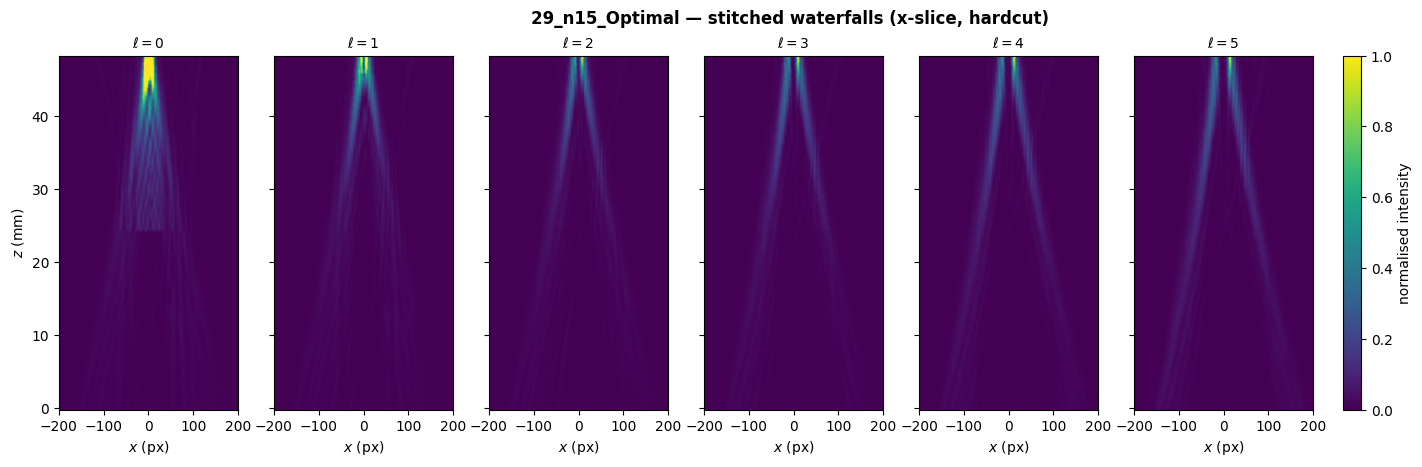

saved per-ell PNGs and the grid to outputs/waterfalls_stitched


In [46]:
CHOSEN_BLEND = "hardcut"   # <- set to "crossfade" or "average" after eyeballing the grid above
assert CHOSEN_BLEND in BLEND_MODES

group = [stitched[ell][CHOSEN_BLEND] for ell in ELLS]

fig, axes = plt.subplots(1, len(group), figsize=(3.0 * len(group) + 1.5, 4.6),
                         sharey=True, squeeze=False)
im = None
for ax, st in zip(axes[0], group):
    im = draw_waterfall(ax, st.waterfall, st.s_px, st.z_mm, f"$\ell={st.ell}$")
    ax.set_ylabel("")
axes[0, 0].set_ylabel("$z$ (mm)")
fig.colorbar(im, ax=axes[0].tolist(), label="normalised intensity", pad=0.02)
fig.suptitle(f"{RUN_LABEL} — stitched waterfalls ({SLICE_AXIS}-slice, {CHOSEN_BLEND})",
             fontweight="bold")
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_grid_{SLICE_AXIS}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# also one PNG per ell
for st in group:
    f, a = plt.subplots(figsize=(5.5, 5.5))
    im = draw_waterfall(a, st.waterfall, st.s_px, st.z_mm,
                        f"{RUN_LABEL}  $\ell={st.ell}$  ({CHOSEN_BLEND})")
    f.colorbar(im, ax=a, label="normalised intensity")
    f.tight_layout()
    f.savefig(OUT_ROOT / f"l={st.ell}_{SLICE_AXIS}.png", dpi=150)
    plt.close(f)
print(f"saved per-ell PNGs and the grid to {OUT_ROOT.relative_to(REPO_ROOT)}")

## Beam width across the full stitched scan

The transverse RMS beam width of the **stitched** waterfall (chosen blend), per $\ell$, over
the whole combined $0 \to \sim48$ mm range. This is the same width feature used to align the
segments (cell 7's `_rms_width`), now measured on the single continuous scan rather than the
two segments separately — so it runs straight through the seam. The overlap band is shaded;
a smooth width curve through it confirms the stitch is clean. Focus is where each curve
bottoms out.

**Note on $\ell=0$:** the donuts (ℓ=1–5) run smoothly through the seam. $\ell=0$ is a Gaussian, not a donut, and its width has no sharp match between the two segments (see the alignment diagnostic), so its curve shows a small step at the seam — expected, and it does not affect the donut results.


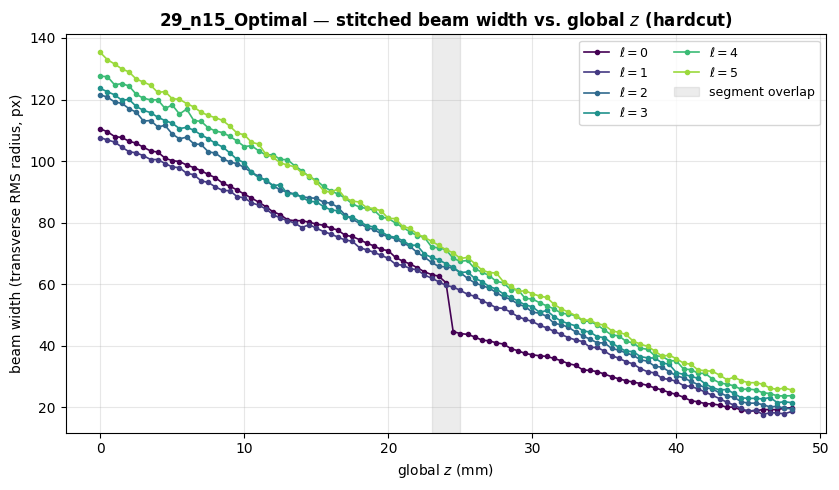

saved 29_n15_Optimal_stitched_width.png


In [47]:
# transverse RMS width of every row of each stitched (combined) waterfall
def stitched_width(st):
    return np.array([_rms_width(row, st.s_px) for row in st.waterfall])

fig, ax = plt.subplots(figsize=(8.5, 5))
colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ELLS)))

for ell, colour in zip(ELLS, colours):
    st = stitched[ell][CHOSEN_BLEND]
    ax.plot(st.z_mm, stitched_width(st), "o-", ms=3, lw=1.2, color=colour,
            label=f"$\\ell={ell}$")

ax.axvspan(OV_LO_MM, OV_HI_MM, color="grey", alpha=0.15, label="segment overlap")
ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel("beam width (transverse RMS radius, px)")
ax.set_title(f"{RUN_LABEL} — stitched beam width vs. global $z$ ({CHOSEN_BLEND})",
             fontweight="bold")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_stitched_width.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved {RUN_LABEL}_stitched_width.png")


## Centroid diagnostic across the stitched scan

The base notebook's centroid figure, on the global $z$ grid. A discontinuity at the seam
(around the overlap band, dashed) would mean the two segments' beams sit at different sensor
positions — expected if the stage/camera shifted between halves, and harmless for the
centred waterfall, but worth seeing.

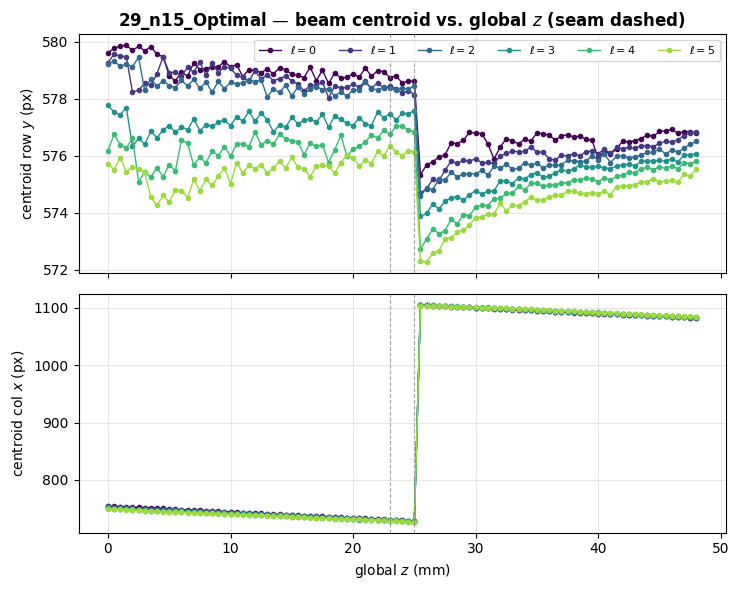

In [48]:
colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ELLS)))
fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
for ell, colour in zip(ELLS, colours):
    st = stitched[ell][CHOSEN_BLEND]
    axes[0].plot(st.z_mm, st.centroid_y, "o-", ms=3, lw=1, color=colour, label=f"$\ell={ell}$")
    axes[1].plot(st.z_mm, st.centroid_x, "o-", ms=3, lw=1, color=colour)
for ax in axes:
    for y in (OV_LO_MM, OV_HI_MM):
        ax.axvline(y, color="grey", ls="--", lw=0.8, alpha=0.7)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("centroid row $y$ (px)")
axes[0].set_title(f"{RUN_LABEL} — beam centroid vs. global $z$ (seam dashed)", fontweight="bold")
axes[0].legend(ncol=len(ELLS), fontsize=8)
axes[1].set_ylabel("centroid col $x$ (px)")
axes[1].set_xlabel("global $z$ (mm)")
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_centroids.png", dpi=150)
plt.show()
plt.close(fig)

## Summary table

One row per $\ell$ for the chosen blend: the stitched $z$ span, the brightest-frame $z$, and
the hand-set segment-2 offset (`seg2_offset_mm`) applied to that charge.


In [49]:
summary = pd.DataFrame([
    {
        "run": RUN_LABEL,
        "ell": ell,
        "blend": CHOSEN_BLEND,
        "n_frames": stitched[ell][CHOSEN_BLEND].z_mm.size,
        "z_min_mm": stitched[ell][CHOSEN_BLEND].z_mm.min(),
        "z_max_mm": stitched[ell][CHOSEN_BLEND].z_mm.max(),
        "brightest_z_mm": stitched[ell][CHOSEN_BLEND].brightest_z,
        "seg2_offset_mm": round(OFFSETS_MM[ell], 2),
    }
    for ell in ELLS
]).round(2)

with pd.option_context("display.max_rows", None, "display.width", 160):
    display(summary)


,run,ell,blend,n_frames,z_min_mm,z_max_mm,brightest_z_mm,seg2_offset_mm
0,29_n15_Optimal,0,hardcut,97,0.0,48.0,43.5,23.0
1,29_n15_Optimal,1,hardcut,97,0.0,48.0,46.5,23.0
2,29_n15_Optimal,2,hardcut,97,0.0,48.0,48.0,23.0
3,29_n15_Optimal,3,hardcut,97,0.0,48.0,48.0,23.0
4,29_n15_Optimal,4,hardcut,97,0.0,48.0,48.0,23.0
5,29_n15_Optimal,5,hardcut,97,0.0,48.0,48.0,23.0
